In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error

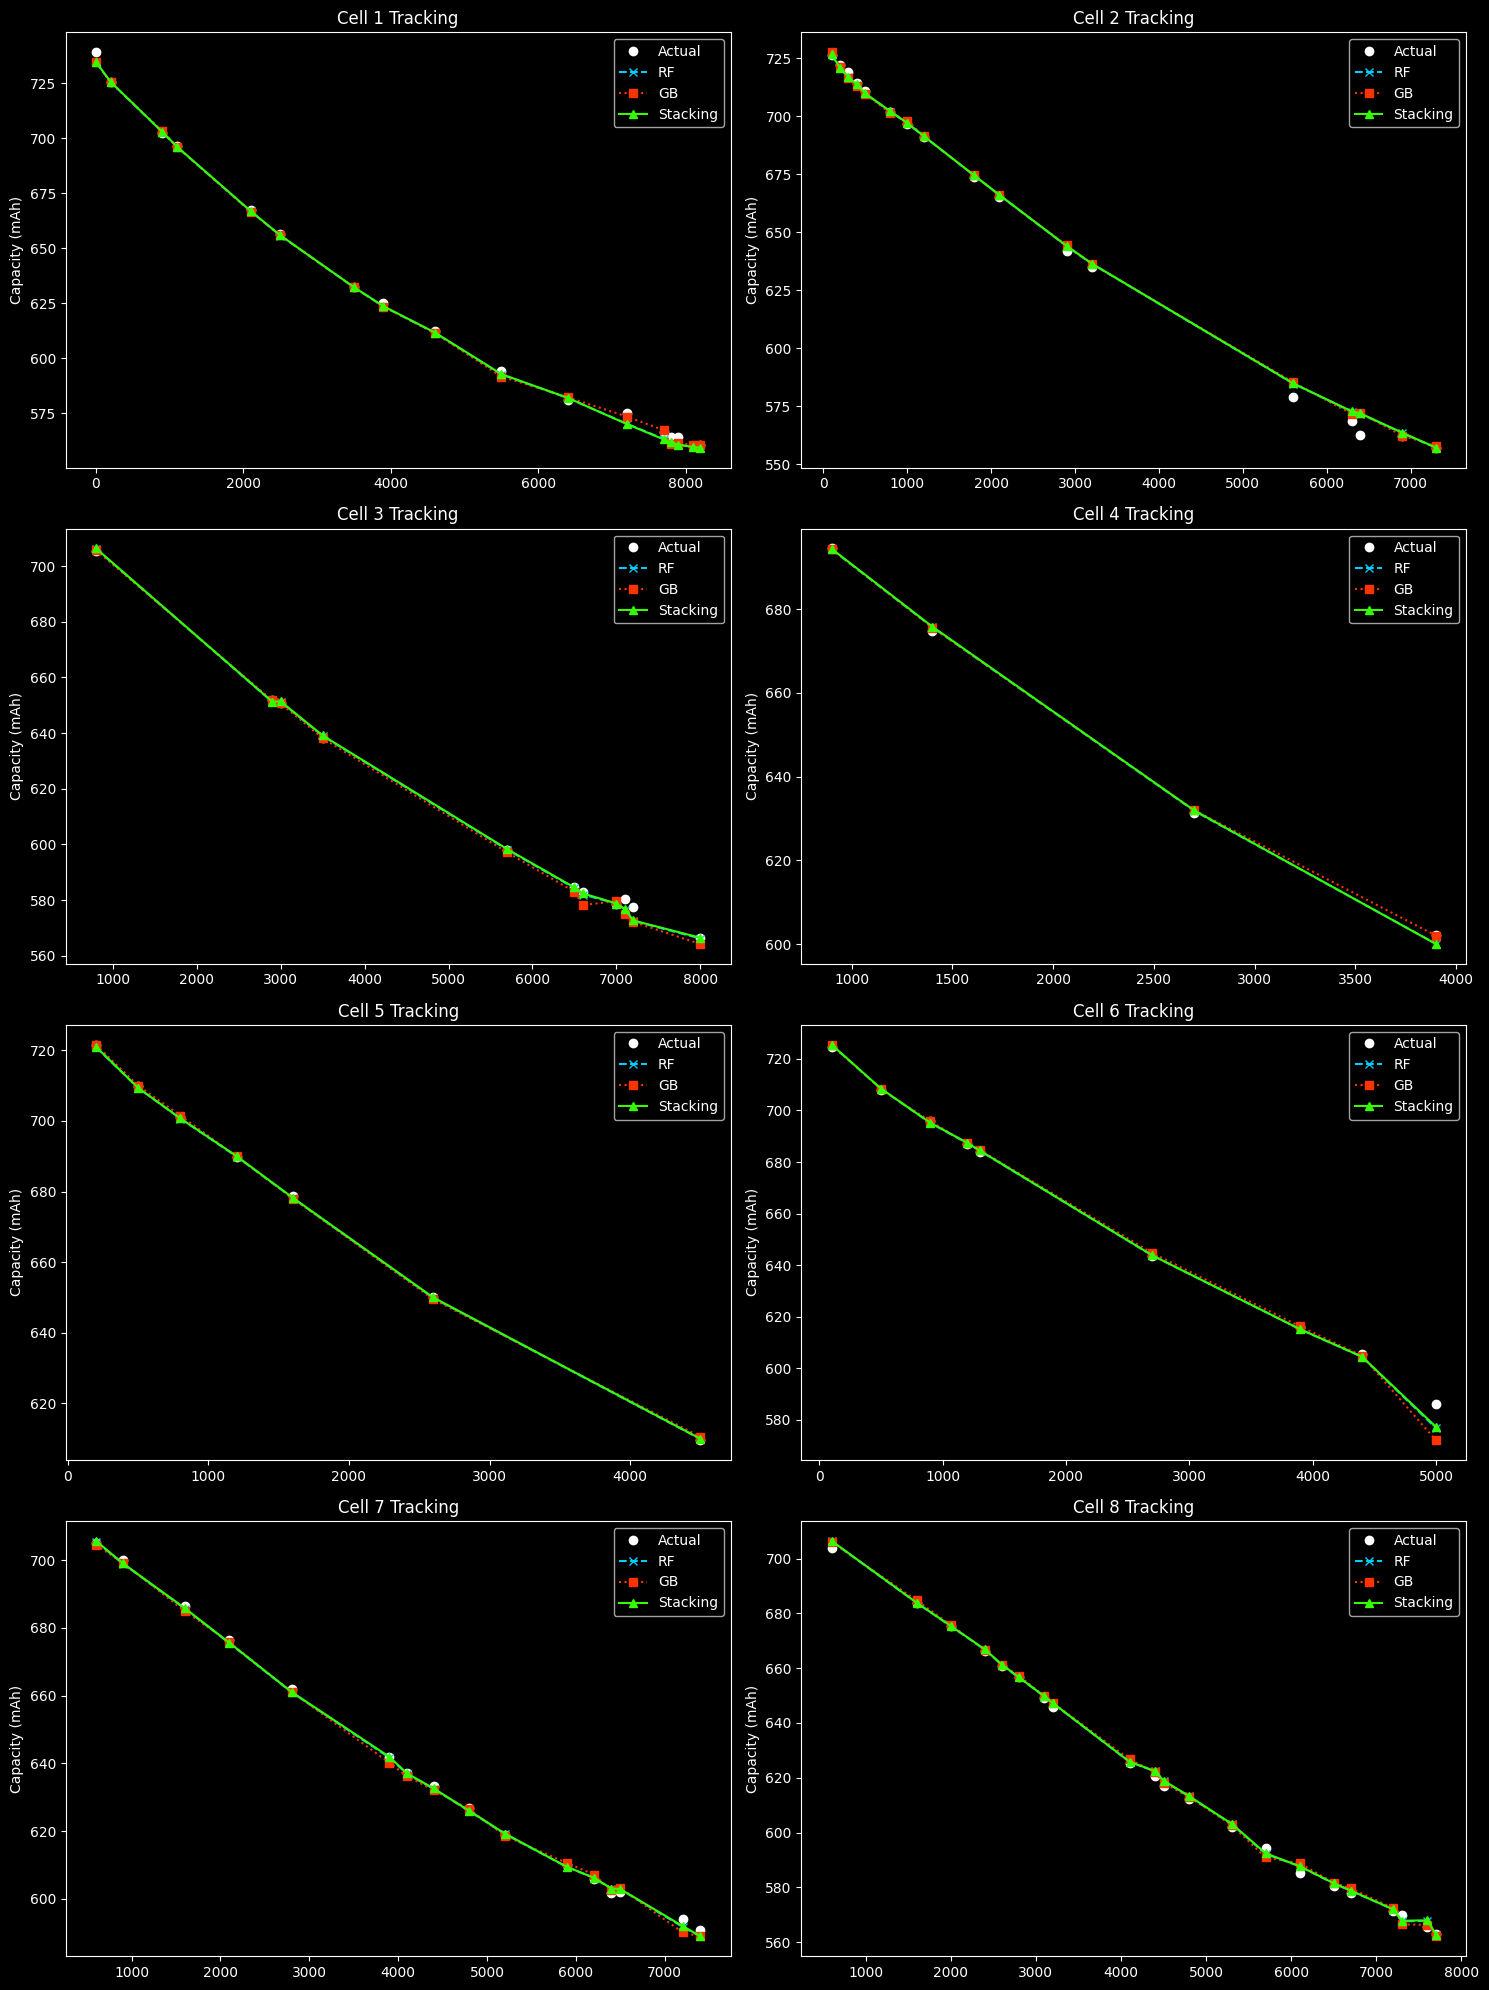

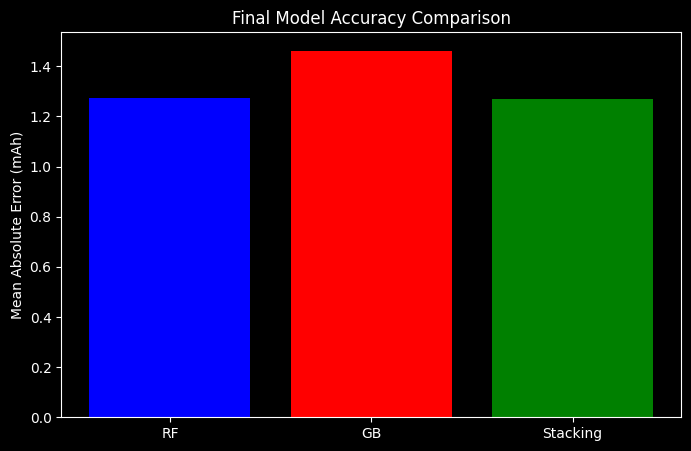

Random Forest MAE: 1.2723
Gradient Boosting MAE: 1.4625
Stacking MAE: 1.2687


In [14]:
plt.style.use('dark_background')
df = pd.read_csv('cleaned_battery_data.csv')

features = ['ica_peak1_V', 'ica_peak1_val', 'ica_peak2_V', 'ica_peak2_val', 'ica_area_abs']
target = 'capacity_mAh'

df_ml = df.dropna(subset=features + [target, 'cell', 'cyc'])
X = df_ml[features]
y = df_ml[target]
info = df_ml[['cell', 'cyc']]

X_train, X_test, y_train, y_test, i_train, i_test = train_test_split(
    X, y, info, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
gb = GradientBoostingRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)

estimators = [('rf', rf), ('gb', gb)]
stack = StackingRegressor(estimators=estimators, final_estimator=RidgeCV()).fit(X_train, y_train)

rf_preds = rf.predict(X_test)
gb_preds = gb.predict(X_test)
stack_preds = stack.predict(X_test)

results = i_test.copy()
results['Actual'], results['RF'], results['GB'], results['Stacking'] = y_test, rf_preds, gb_preds, stack_preds

cells = sorted(results['cell'].unique())
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

for i, cell_id in enumerate(cells):
    c_data = results[results['cell'] == cell_id].sort_values('cyc')
    axes[i].plot(c_data['cyc'], c_data['Actual'], 'o', label='Actual', color='#FFFFFF', alpha=1)
    axes[i].plot(c_data['cyc'], c_data['RF'], 'x--', label='RF', color='#00CCFF')
    axes[i].plot(c_data['cyc'], c_data['GB'], 's:', label='GB', color='#FF3300')
    axes[i].plot(c_data['cyc'], c_data['Stacking'], '^-', label='Stacking', color='#33FF00')
    axes[i].set_title(f'Cell {cell_id} Tracking')
    axes[i].set_ylabel('Capacity (mAh)')
    axes[i].legend()

plt.tight_layout()
plt.show()

maes = {"RF": mean_absolute_error(y_test, rf_preds), 
        "GB": mean_absolute_error(y_test, gb_preds), 
        "Stacking": mean_absolute_error(y_test, stack_preds)}

plt.figure(figsize=(8, 5))
plt.bar(maes.keys(), maes.values(), color=['blue', 'red', 'green'])
plt.ylabel('Mean Absolute Error (mAh)')
plt.title('Final Model Accuracy Comparison')
plt.show()

print(f"Random Forest MAE: {mean_absolute_error(y_test, rf_preds):.4f}")
print(f"Gradient Boosting MAE: {mean_absolute_error(y_test, gb_preds):.4f}")
print(f"Stacking MAE: {mean_absolute_error(y_test, stack_preds):.4f}")